In [2]:
import pandas as pd

# Load final dataset
df = pd.read_csv("final_data_center_esg_ml_dataset.csv")

## Step 1: Dataset Understanding

### What we are going to do

In this step, we will understand the structure and purpose of the dataset before performing analysis or machine learning.

We will check:

- How many rows and columns are present in the dataset
- What each table and column represents
- Whether the dataset contains energy, financial, ESG, and operational variables
- Which columns are useful for business analysis
- Which columns can be used for machine learning
- What the target variables are for regression and classification

The goal of this step is to understand how the dataset can help identify data center energy waste, revenue leakage, Scope 2 emissions, and operational risk.

### Expected outcome

By the end of this step, we should clearly know:

- Each row represents one data center site on one date
- The dataset contains 1,825 records and 43 columns
- The main business metric is `revenue_leakage_usd`
- The regression target is `energy_waste_cost_usd`
- The classification target is `risk_level`

In [3]:
import pandas as pd
from pathlib import Path

print("Current Jupyter folder:")
print(Path.cwd())

df = pd.read_csv("final_data_center_esg_ml_dataset.csv")

print("File loaded successfully")
print("Shape:", df.shape)
df.head()

Current Jupyter folder:
/Users/ruchigaur/1. DATA CENTER ESG
File loaded successfully
Shape: (1825, 43)


,date,site_id,site_name,city,country,capacity_mw,cooling_type,energy_tariff_per_kwh,grid_emission_factor,renewable_energy_percent,...,renewable_kwh,fossil_power_kwh,scope_2_emissions_tco2e,carbon_intensity_kg_per_kwh,pue,non_it_energy_kwh,energy_waste_cost_usd,revenue_leakage_usd,target_pue,risk_level
0,2024-01-01,DC001,Mumbai Core DC,Mumbai,India,45,Air Cooling,0.110,0.72,18,...,200869.52,915072.26,658.85,0.5904,1.711,463618.10,11532.41,11532.41,1.55,High
1,2024-01-01,DC002,Bengaluru AI Hub,Bengaluru,India,60,Liquid Cooling,0.090,0.62,42,...,499453.30,689721.22,427.63,0.3596,1.426,355229.40,5701.37,5701.37,1.35,Medium
2,2024-01-01,DC003,Delhi Enterprise DC,Delhi,India,35,Air Cooling,0.120,0.75,15,...,113613.42,643809.40,482.86,0.6375,1.710,314449.81,8497.76,8497.76,1.55,Medium
3,2024-01-01,DC004,Hyderabad Cloud DC,Hyderabad,India,50,Hybrid Cooling,0.100,0.66,35,...,368841.84,684991.98,452.09,0.4290,1.560,378213.49,7418.43,7418.43,1.45,Medium
4,2024-01-01,DC005,Pune Backup DC,Pune,India,30,Air Cooling,0.095,0.68,28,...,166970.18,429351.89,291.96,0.4896,1.704,246299.38,5109.76,5109.76,1.55,Medium


In [4]:
# Basic dataset info
print("Dataset shape:")
print(df.shape)

Dataset shape:
(1825, 43)


In [5]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
         date site_id            site_name       city country  capacity_mw  \
0  2024-01-01   DC001       Mumbai Core DC     Mumbai   India           45   
1  2024-01-01   DC002     Bengaluru AI Hub  Bengaluru   India           60   
2  2024-01-01   DC003  Delhi Enterprise DC      Delhi   India           35   
3  2024-01-01   DC004   Hyderabad Cloud DC  Hyderabad   India           50   
4  2024-01-01   DC005       Pune Backup DC       Pune   India           30   

     cooling_type  energy_tariff_per_kwh  grid_emission_factor  \
0     Air Cooling                  0.110                  0.72   
1  Liquid Cooling                  0.090                  0.62   
2     Air Cooling                  0.120                  0.75   
3  Hybrid Cooling                  0.100                  0.66   
4     Air Cooling                  0.095                  0.68   

   renewable_energy_percent  ...  renewable_kwh  fossil_power_kwh  \
0                        18  ...      200869.52   

In [6]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['date', 'site_id', 'site_name', 'city', 'country', 'capacity_mw', 'cooling_type', 'energy_tariff_per_kwh', 'grid_emission_factor', 'renewable_energy_percent', 'building_age_years', 'sla_target_percent', 'total_facility_energy_kwh', 'it_equipment_energy_kwh', 'cooling_energy_kwh', 'lighting_energy_kwh', 'backup_power_kwh', 'peak_demand_kw', 'temperature_celsius', 'humidity_percent', 'server_count', 'active_servers', 'idle_servers', 'avg_cpu_utilization_percent', 'storage_utilization_percent', 'ai_workload_percent', 'revenue_usd', 'energy_cost_usd', 'cooling_cost_usd', 'maintenance_cost_usd', 'downtime_minutes', 'sla_penalty_usd', 'gross_margin_percent', 'renewable_kwh', 'fossil_power_kwh', 'scope_2_emissions_tco2e', 'carbon_intensity_kg_per_kwh', 'pue', 'non_it_energy_kwh', 'energy_waste_cost_usd', 'revenue_leakage_usd', 'target_pue', 'risk_level']


In [7]:
print("\nData types:")
print(df.dtypes)



Data types:
date                            object
site_id                         object
site_name                       object
city                            object
country                         object
capacity_mw                      int64
cooling_type                    object
energy_tariff_per_kwh          float64
grid_emission_factor           float64
renewable_energy_percent         int64
building_age_years               int64
sla_target_percent             float64
total_facility_energy_kwh      float64
it_equipment_energy_kwh        float64
cooling_energy_kwh             float64
lighting_energy_kwh            float64
backup_power_kwh               float64
peak_demand_kw                 float64
temperature_celsius            float64
humidity_percent               float64
server_count                     int64
active_servers                   int64
idle_servers                     int64
avg_cpu_utilization_percent    float64
storage_utilization_percent    float64
ai_workload_

In [8]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
date                           0
site_id                        0
site_name                      0
city                           0
country                        0
capacity_mw                    0
cooling_type                   0
energy_tariff_per_kwh          0
grid_emission_factor           0
renewable_energy_percent       0
building_age_years             0
sla_target_percent             0
total_facility_energy_kwh      0
it_equipment_energy_kwh        0
cooling_energy_kwh             0
lighting_energy_kwh            0
backup_power_kwh               0
peak_demand_kw                 0
temperature_celsius            0
humidity_percent               0
server_count                   0
active_servers                 0
idle_servers                   0
avg_cpu_utilization_percent    0
storage_utilization_percent    0
ai_workload_percent            0
revenue_usd                    0
energy_cost_usd                0
cooling_cost_usd               0
maintenance_cost_usd      

In [9]:
print("\nDuplicate rows:")
print(df.duplicated().sum())



Duplicate rows:
0


In [10]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       capacity_mw  energy_tariff_per_kwh  grid_emission_factor  \
count  1825.000000            1825.000000           1825.000000   
mean     44.000000               0.103000              0.686000   
std      10.680005               0.010773              0.045444   
min      30.000000               0.090000              0.620000   
25%      35.000000               0.095000              0.660000   
50%      45.000000               0.100000              0.680000   
75%      50.000000               0.110000              0.720000   
max      60.000000               0.120000              0.750000   

       renewable_energy_percent  building_age_years  sla_target_percent  \
count               1825.000000         1825.000000         1825.000000   
mean                  27.600000            7.800000           99.900000   
std                   10.133917            2.713676            0.054787   
min                   15.000000            4.000000           99.800000   


In [11]:
# Step 1 final checks: ML target and business KPI understanding

print("Energy waste cost summary:")
print(df["energy_waste_cost_usd"].describe())

print("\nRevenue leakage summary:")
print(df["revenue_leakage_usd"].describe())

print("\nRisk level distribution:")
print(df["risk_level"].value_counts())

print("\nAverage PUE by site:")
print(
    df.groupby("site_name")["pue"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTotal revenue leakage by site:")
print(
    df.groupby("site_name")["revenue_leakage_usd"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal Scope 2 emissions by site:")
print(
    df.groupby("site_name")["scope_2_emissions_tco2e"]
    .sum()
    .sort_values(ascending=False)
)

Energy waste cost summary:
count     1825.000000
mean     11638.445518
std       5455.882964
min       2511.930000
25%       7055.140000
50%      10167.290000
75%      15884.070000
max      29137.370000
Name: energy_waste_cost_usd, dtype: float64

Revenue leakage summary:
count      1825.000000
mean      17361.294510
std       25998.717201
min        2511.930000
25%        7237.260000
50%       10960.430000
75%       16965.280000
max      346177.390000
Name: revenue_leakage_usd, dtype: float64

Risk level distribution:
risk_level
Medium    1160
High       518
Low        147
Name: count, dtype: int64

Average PUE by site:
site_name
Delhi Enterprise DC    1.847529
Mumbai Core DC         1.799797
Pune Backup DC         1.753849
Hyderabad Cloud DC     1.594715
Bengaluru AI Hub       1.448471
Name: pue, dtype: float64

Total revenue leakage by site:
site_name
Delhi Enterprise DC    10432126.00
Mumbai Core DC          8635261.40
Hyderabad Cloud DC      5032068.37
Pune Backup DC          4239

## Step 1: Dataset Understanding Summary 

The dataset contains 1,825 records and 43 columns. Each row represents one data center site on one date.

The dataset combines site information, energy consumption, server utilization, financial performance, and ESG emissions. This makes it useful for both business analysis and machine learning.

No duplicate records were found in the dataset.

The main business metric is `revenue_leakage_usd`, which combines energy waste cost and SLA penalty impact.

The main machine learning targets are:

- `energy_waste_cost_usd` for regression
- `risk_level` for classification

This dataset can help identify which data centers are inefficient, which sites are creating high emissions, and where the company is losing profit due to energy waste.

## Step 2: Data Cleaning and Validation

### What we are going to do

In this step, we will check whether the dataset is clean, valid, and ready for analysis.

We will validate:

- Missing values
- Duplicate records
- Data types
- Date format
- Negative values in energy, cost, emissions, and server columns
- Percentage columns such as CPU utilization, renewable energy share, and gross margin
- PUE values to make sure they are realistic
- Risk level labels to make sure only valid categories exist
- Business formulas such as PUE and revenue leakage

The goal of this step is to make sure the dataset is reliable before creating KPIs, dashboards, and machine learning models.

### Expected outcome

By the end of this step, we should have:

- A cleaned dataset
- Correct date format
- No duplicate records
- No major data quality issues
- Valid PUE values
- Valid risk level labels
- Confirmed formulas for PUE and revenue leakage

The cleaned file will be saved as:

`clean_data_center_esg_ml_dataset.csv`


In [12]:
# Step 2: Data Cleaning and Validation

import pandas as pd

# Make a copy so original dataframe stays safe
df_clean = df.copy()

print("Starting dataset shape:", df_clean.shape)

# Convert date column to datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

print("\nDate column converted successfully")
print(df_clean["date"].dtype)

# Check missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

# Check data types
print("\nData types:")
print(df_clean.dtypes)

Starting dataset shape: (1825, 43)

Date column converted successfully
datetime64[ns]

Missing values:
date                           0
site_id                        0
site_name                      0
city                           0
country                        0
capacity_mw                    0
cooling_type                   0
energy_tariff_per_kwh          0
grid_emission_factor           0
renewable_energy_percent       0
building_age_years             0
sla_target_percent             0
total_facility_energy_kwh      0
it_equipment_energy_kwh        0
cooling_energy_kwh             0
lighting_energy_kwh            0
backup_power_kwh               0
peak_demand_kw                 0
temperature_celsius            0
humidity_percent               0
server_count                   0
active_servers                 0
idle_servers                   0
avg_cpu_utilization_percent    0
storage_utilization_percent    0
ai_workload_percent            0
revenue_usd                    0
energy

In [13]:
# Columns where negative values should not exist

non_negative_columns = [
    "capacity_mw",
    "energy_tariff_per_kwh",
    "grid_emission_factor",
    "renewable_energy_percent",
    "building_age_years",
    "total_facility_energy_kwh",
    "it_equipment_energy_kwh",
    "cooling_energy_kwh",
    "lighting_energy_kwh",
    "backup_power_kwh",
    "peak_demand_kw",
    "server_count",
    "active_servers",
    "idle_servers",
    "avg_cpu_utilization_percent",
    "storage_utilization_percent",
    "ai_workload_percent",
    "revenue_usd",
    "energy_cost_usd",
    "cooling_cost_usd",
    "maintenance_cost_usd",
    "downtime_minutes",
    "sla_penalty_usd",
    "renewable_kwh",
    "fossil_power_kwh",
    "scope_2_emissions_tco2e",
    "carbon_intensity_kg_per_kwh",
    "pue",
    "non_it_energy_kwh",
    "energy_waste_cost_usd",
    "revenue_leakage_usd"
]

for col in non_negative_columns:
    negative_count = (df_clean[col] < 0).sum()
    print(col, "negative values:", negative_count)

capacity_mw negative values: 0
energy_tariff_per_kwh negative values: 0
grid_emission_factor negative values: 0
renewable_energy_percent negative values: 0
building_age_years negative values: 0
total_facility_energy_kwh negative values: 0
it_equipment_energy_kwh negative values: 0
cooling_energy_kwh negative values: 0
lighting_energy_kwh negative values: 0
backup_power_kwh negative values: 0
peak_demand_kw negative values: 0
server_count negative values: 0
active_servers negative values: 0
idle_servers negative values: 0
avg_cpu_utilization_percent negative values: 0
storage_utilization_percent negative values: 0
ai_workload_percent negative values: 0
revenue_usd negative values: 0
energy_cost_usd negative values: 0
cooling_cost_usd negative values: 0
maintenance_cost_usd negative values: 0
downtime_minutes negative values: 0
sla_penalty_usd negative values: 0
renewable_kwh negative values: 0
fossil_power_kwh negative values: 0
scope_2_emissions_tco2e negative values: 0
carbon_intensit

In [14]:
# Percentage columns should be between 0 and 100

percentage_columns = [
    "renewable_energy_percent",
    "sla_target_percent",
    "humidity_percent",
    "avg_cpu_utilization_percent",
    "storage_utilization_percent",
    "ai_workload_percent",
    "gross_margin_percent"
]

for col in percentage_columns:
    print("\n", col)
    print("Minimum:", df_clean[col].min())
    print("Maximum:", df_clean[col].max())


 renewable_energy_percent
Minimum: 15
Maximum: 42

 sla_target_percent
Minimum: 99.8
Maximum: 99.95

 humidity_percent
Minimum: 35.0
Maximum: 87.03

 avg_cpu_utilization_percent
Minimum: 22.0
Maximum: 88.0

 storage_utilization_percent
Minimum: 40.0
Maximum: 92.0

 ai_workload_percent
Minimum: 10.0
Maximum: 74.75

 gross_margin_percent
Minimum: -7.69
Maximum: 82.47


In [15]:
# Validate PUE range

print("PUE summary:")
print(df_clean["pue"].describe())

print("\nRows with PUE below 1:")
print(df_clean[df_clean["pue"] < 1])

print("\nRows with very high PUE above 3:")
print(df_clean[df_clean["pue"] > 3])

PUE summary:
count    1825.000000
mean        1.688872
std         0.154370
min         1.386000
25%         1.566000
50%         1.734000
75%         1.812000
max         2.012000
Name: pue, dtype: float64

Rows with PUE below 1:
Empty DataFrame
Columns: [date, site_id, site_name, city, country, capacity_mw, cooling_type, energy_tariff_per_kwh, grid_emission_factor, renewable_energy_percent, building_age_years, sla_target_percent, total_facility_energy_kwh, it_equipment_energy_kwh, cooling_energy_kwh, lighting_energy_kwh, backup_power_kwh, peak_demand_kw, temperature_celsius, humidity_percent, server_count, active_servers, idle_servers, avg_cpu_utilization_percent, storage_utilization_percent, ai_workload_percent, revenue_usd, energy_cost_usd, cooling_cost_usd, maintenance_cost_usd, downtime_minutes, sla_penalty_usd, gross_margin_percent, renewable_kwh, fossil_power_kwh, scope_2_emissions_tco2e, carbon_intensity_kg_per_kwh, pue, non_it_energy_kwh, energy_waste_cost_usd, revenue_leakag

# The average PUE across all data centers is 1.69, indicating moderate inefficiency. No invalid PUE values were found, but multiple sites operate above the ideal efficiency range, creating energy waste and profit leakage.

In [16]:
# Validate risk level labels

print("Unique risk levels:")
print(df_clean["risk_level"].unique())

print("\nRisk level count:")
print(df_clean["risk_level"].value_counts())

Unique risk levels:
['High' 'Medium' 'Low']

Risk level count:
risk_level
Medium    1160
High       518
Low        147
Name: count, dtype: int64


# Revenue Leakage = Energy Waste Cost + SLA Penalty

In [17]:
# Validate revenue leakage calculation

df_clean["revenue_leakage_check"] = (
    df_clean["energy_waste_cost_usd"] + df_clean["sla_penalty_usd"]
)

df_clean["revenue_leakage_difference"] = (
    df_clean["revenue_leakage_usd"] - df_clean["revenue_leakage_check"]
)

print("Revenue leakage difference summary:")
print(df_clean["revenue_leakage_difference"].describe())

print("\nMaximum absolute difference:")
print(df_clean["revenue_leakage_difference"].abs().max())

Revenue leakage difference summary:
count    1825.000000
mean       -0.000022
std         0.001622
min        -0.010000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.010000
Name: revenue_leakage_difference, dtype: float64

Maximum absolute difference:
0.010000000009313226


# PUE = Total Facility Energy / IT Equipment Energy

In [18]:
# Validate PUE calculation

df_clean["pue_check"] = (
    df_clean["total_facility_energy_kwh"] / df_clean["it_equipment_energy_kwh"]
)

df_clean["pue_difference"] = df_clean["pue"] - df_clean["pue_check"]

print("PUE difference summary:")
print(df_clean["pue_difference"].describe())

print("\nMaximum absolute difference:")
print(df_clean["pue_difference"].abs().max())

PUE difference summary:
count    1.825000e+03
mean     4.366149e-07
std      2.868447e-04
min     -4.993360e-04
25%     -2.442434e-04
50%     -1.198090e-05
75%      2.478708e-04
max      4.997840e-04
Name: pue_difference, dtype: float64

Maximum absolute difference:
0.0004997840071292448


In [19]:
# Drop temporary validation columns safely

columns_to_drop = [
    "revenue_leakage_check",
    "revenue_leakage_difference",
    "pue_check",
    "pue_difference"
]

df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

# Save clean dataset in current Jupyter folder
df_clean.to_csv("clean_data_center_esg_ml_dataset.csv", index=False)

print("Clean dataset saved successfully")
print("Final clean shape:", df_clean.shape)

Clean dataset saved successfully
Final clean shape: (1825, 43)


## Step 2: Data Cleaning and Validation Summary 

The dataset was checked for missing values, duplicate records, incorrect data types, negative values, invalid percentage ranges, unrealistic PUE values, and incorrect risk labels.

The `date` column was converted into datetime format.

The core business formulas were validated:

- PUE = Total Facility Energy / IT Equipment Energy
- Revenue Leakage = Energy Waste Cost + SLA Penalty

No major data quality issues were found. The cleaned dataset was saved as `clean_data_center_esg_ml_dataset.csv`.

This cleaned dataset will be used for KPI analysis, EDA, SQL questions, dashboarding, and machine learning.

## Step 3: KPI Creation and Feature Engineering

### What we are going to do

In this step, we will create new business KPIs and machine learning features from the cleaned dataset.

We will create features for:

- Date analysis such as month, quarter, weekday, and weekend flag
- Energy efficiency such as cooling energy share, IT energy share, and non-IT energy share
- Renewable and fossil energy share
- Financial leakage such as energy cost percentage, cooling cost percentage, and revenue leakage percentage
- Server efficiency such as server utilization rate, idle server rate, and energy per active server
- ESG intensity such as emissions per USD revenue
- Operational demand such as average demand and peak-to-average demand ratio
- PUE gap from target
- Business status labels for PUE, revenue leakage, and carbon risk

The goal of this step is to convert raw operational data into useful business and ML-ready features.

### Expected outcome

By the end of this step, we should have:

- A feature-engineered dataset ready for EDA and ML
- New KPI columns for business analysis
- Status labels for dashboarding
- A site-level summary table for leadership insights

The final files will be saved as:

`feature_engineered_data_center_esg_ml_dataset.csv`

`site_kpi_summary.csv`


In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load clean dataset
df_kpi = pd.read_csv("clean_data_center_esg_ml_dataset.csv")

print("Dataset loaded")
print("Shape:", df_kpi.shape)

df_kpi.head()

Dataset loaded
Shape: (1825, 43)


,date,site_id,site_name,city,country,capacity_mw,cooling_type,energy_tariff_per_kwh,grid_emission_factor,renewable_energy_percent,...,renewable_kwh,fossil_power_kwh,scope_2_emissions_tco2e,carbon_intensity_kg_per_kwh,pue,non_it_energy_kwh,energy_waste_cost_usd,revenue_leakage_usd,target_pue,risk_level
0,2024-01-01,DC001,Mumbai Core DC,Mumbai,India,45,Air Cooling,0.110,0.72,18,...,200869.52,915072.26,658.85,0.5904,1.711,463618.10,11532.41,11532.41,1.55,High
1,2024-01-01,DC002,Bengaluru AI Hub,Bengaluru,India,60,Liquid Cooling,0.090,0.62,42,...,499453.30,689721.22,427.63,0.3596,1.426,355229.40,5701.37,5701.37,1.35,Medium
2,2024-01-01,DC003,Delhi Enterprise DC,Delhi,India,35,Air Cooling,0.120,0.75,15,...,113613.42,643809.40,482.86,0.6375,1.710,314449.81,8497.76,8497.76,1.55,Medium
3,2024-01-01,DC004,Hyderabad Cloud DC,Hyderabad,India,50,Hybrid Cooling,0.100,0.66,35,...,368841.84,684991.98,452.09,0.4290,1.560,378213.49,7418.43,7418.43,1.45,Medium
4,2024-01-01,DC005,Pune Backup DC,Pune,India,30,Air Cooling,0.095,0.68,28,...,166970.18,429351.89,291.96,0.4896,1.704,246299.38,5109.76,5109.76,1.55,Medium


In [21]:
# Convert date column to datetime
df_kpi["date"] = pd.to_datetime(df_kpi["date"])

# Create date-based features for trend analysis and ML
df_kpi["year"] = df_kpi["date"].dt.year
df_kpi["month"] = df_kpi["date"].dt.month
df_kpi["month_name"] = df_kpi["date"].dt.month_name()
df_kpi["quarter"] = df_kpi["date"].dt.quarter
df_kpi["day_of_week"] = df_kpi["date"].dt.day_name()
df_kpi["is_weekend"] = df_kpi["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

print("Date features created successfully")

df_kpi[
    ["date", "year", "month", "month_name", "quarter", "day_of_week", "is_weekend"]
].head()

Date features created successfully


,date,year,month,month_name,quarter,day_of_week,is_weekend
0,2024-01-01,2024,1,January,1,Monday,0
1,2024-01-01,2024,1,January,1,Monday,0
2,2024-01-01,2024,1,January,1,Monday,0
3,2024-01-01,2024,1,January,1,Monday,0
4,2024-01-01,2024,1,January,1,Monday,0


### Business KPI Features

These features convert raw operational data into business-ready metrics for energy efficiency, cost leakage, ESG impact, server utilization, and ML prediction.

In [22]:
# Energy efficiency features
df_kpi["cooling_energy_share_percent"] = (
    df_kpi["cooling_energy_kwh"] / df_kpi["total_facility_energy_kwh"]
) * 100

df_kpi["it_energy_share_percent"] = (
    df_kpi["it_equipment_energy_kwh"] / df_kpi["total_facility_energy_kwh"]
) * 100

df_kpi["non_it_energy_share_percent"] = (
    df_kpi["non_it_energy_kwh"] / df_kpi["total_facility_energy_kwh"]
) * 100

# Renewable and fossil power shares
df_kpi["actual_renewable_share_percent"] = (
    df_kpi["renewable_kwh"] / df_kpi["total_facility_energy_kwh"]
) * 100

df_kpi["actual_fossil_share_percent"] = (
    df_kpi["fossil_power_kwh"] / df_kpi["total_facility_energy_kwh"]
) * 100

# Financial leakage features
df_kpi["energy_cost_as_percent_of_revenue"] = (
    df_kpi["energy_cost_usd"] / df_kpi["revenue_usd"]
) * 100

df_kpi["cooling_cost_as_percent_of_revenue"] = (
    df_kpi["cooling_cost_usd"] / df_kpi["revenue_usd"]
) * 100

df_kpi["revenue_leakage_percent"] = (
    df_kpi["revenue_leakage_usd"] / df_kpi["revenue_usd"]
) * 100

# Server efficiency features
df_kpi["server_utilization_rate_percent"] = (
    df_kpi["active_servers"] / df_kpi["server_count"]
) * 100

df_kpi["idle_server_rate_percent"] = (
    df_kpi["idle_servers"] / df_kpi["server_count"]
) * 100

df_kpi["energy_per_active_server_kwh"] = (
    df_kpi["total_facility_energy_kwh"] / df_kpi["active_servers"]
)

# ESG financial intensity
df_kpi["emissions_kg_per_usd_revenue"] = (
    df_kpi["scope_2_emissions_tco2e"] * 1000 / df_kpi["revenue_usd"]
)

# Operational load feature
df_kpi["avg_demand_kw"] = df_kpi["total_facility_energy_kwh"] / 24

df_kpi["peak_to_average_demand_ratio"] = (
    df_kpi["peak_demand_kw"] / df_kpi["avg_demand_kw"]
)

# PUE gap from target
df_kpi["pue_gap"] = df_kpi["pue"] - df_kpi["target_pue"]

df_kpi["pue_gap_percent"] = (
    df_kpi["pue_gap"] / df_kpi["target_pue"]
) * 100

print("Business KPI features created successfully")
print("New dataset shape:", df_kpi.shape)

Business KPI features created successfully
New dataset shape: (1825, 65)


### Business Status Labels

These labels convert numeric KPIs into business-friendly categories for dashboards, stakeholder reporting, and ML interpretation.

In [23]:
# Create PUE status labels

def pue_status(pue):
    if pue <= 1.40:
        return "Excellent"
    elif pue <= 1.60:
        return "Good"
    elif pue <= 1.80:
        return "Poor"
    else:
        return "Critical"

df_kpi["pue_status"] = df_kpi["pue"].apply(pue_status)


# Create revenue leakage status labels

def leakage_status(leakage_percent):
    if leakage_percent < 2:
        return "Low Leakage"
    elif leakage_percent < 5:
        return "Medium Leakage"
    else:
        return "High Leakage"

df_kpi["revenue_leakage_status"] = df_kpi["revenue_leakage_percent"].apply(leakage_status)


# Create carbon risk status labels

def carbon_risk(emissions):
    if emissions < 350:
        return "Low Carbon Risk"
    elif emissions < 600:
        return "Medium Carbon Risk"
    else:
        return "High Carbon Risk"

df_kpi["carbon_risk_status"] = df_kpi["scope_2_emissions_tco2e"].apply(carbon_risk)


print("Status labels created successfully")
print("New dataset shape:", df_kpi.shape)

df_kpi[
    [
        "site_name",
        "date",
        "pue",
        "pue_status",
        "revenue_leakage_percent",
        "revenue_leakage_status",
        "scope_2_emissions_tco2e",
        "carbon_risk_status"
    ]
].head()

Status labels created successfully
New dataset shape: (1825, 68)


,site_name,date,pue,pue_status,revenue_leakage_percent,revenue_leakage_status,scope_2_emissions_tco2e,carbon_risk_status
0,Mumbai Core DC,2024-01-01,1.711,Poor,2.154035,Medium Leakage,658.85,High Carbon Risk
1,Bengaluru AI Hub,2024-01-01,1.426,Good,0.734369,Low Leakage,427.63,Medium Carbon Risk
2,Delhi Enterprise DC,2024-01-01,1.710,Poor,1.904516,Low Leakage,482.86,Medium Carbon Risk
3,Hyderabad Cloud DC,2024-01-01,1.560,Good,1.162374,Low Leakage,452.09,Medium Carbon Risk
4,Pune Backup DC,2024-01-01,1.704,Poor,1.591668,Low Leakage,291.96,Low Carbon Risk


### Site-Level Business Summary

This summary aggregates daily records into site-level KPIs to identify which data centers have the highest energy cost, revenue leakage, Scope 2 emissions, and operational inefficiency.

In [24]:
site_kpi_summary = (
    df_kpi.groupby(["site_id", "site_name", "city", "cooling_type"])
    .agg(
        avg_pue=("pue", "mean"),
        avg_pue_gap=("pue_gap", "mean"),
        total_energy_kwh=("total_facility_energy_kwh", "sum"),
        total_energy_cost_usd=("energy_cost_usd", "sum"),
        total_cooling_cost_usd=("cooling_cost_usd", "sum"),
        total_revenue_usd=("revenue_usd", "sum"),
        total_revenue_leakage_usd=("revenue_leakage_usd", "sum"),
        avg_revenue_leakage_percent=("revenue_leakage_percent", "mean"),
        total_scope_2_emissions_tco2e=("scope_2_emissions_tco2e", "sum"),
        avg_server_utilization=("server_utilization_rate_percent", "mean"),
        avg_idle_server_rate=("idle_server_rate_percent", "mean"),
        avg_gross_margin=("gross_margin_percent", "mean")
    )
    .reset_index()
)

site_kpi_summary = site_kpi_summary.sort_values(
    by="total_revenue_leakage_usd",
    ascending=False
)

site_kpi_summary

,site_id,site_name,city,cooling_type,avg_pue,avg_pue_gap,total_energy_kwh,total_energy_cost_usd,total_cooling_cost_usd,total_revenue_usd,total_revenue_leakage_usd,avg_revenue_leakage_percent,total_scope_2_emissions_tco2e,avg_server_utilization,avg_idle_server_rate,avg_gross_margin
2,DC003,Delhi Enterprise DC,Delhi,Air Cooling,1.847529,0.297529,3.174791e+08,38097494.31,14570099.09,1.551894e+08,10432126.00,6.731829,202392.91,71.816372,28.183628,62.110082
0,DC001,Mumbai Core DC,Mumbai,Air Cooling,1.799797,0.249797,4.186479e+08,46051264.73,16949197.74,1.951720e+08,8635261.40,4.410812,247169.77,71.184247,28.815753,65.922740
3,DC004,Hyderabad Cloud DC,Hyderabad,Hybrid Cooling,1.594715,0.144715,3.963505e+08,39635048.93,11557698.30,2.328550e+08,5032068.37,2.170810,170034.30,72.315293,27.684707,74.263671
4,DC005,Pune Backup DC,Pune,Air Cooling,1.753849,0.203849,2.216304e+08,21054887.44,7430218.30,1.132069e+08,4239047.36,3.722048,108510.28,72.305355,27.694645,68.372164
1,DC002,Bengaluru AI Hub,Bengaluru,Liquid Cooling,1.448471,0.098471,4.363638e+08,39272742.65,8681309.07,2.819959e+08,3345859.35,1.195106,156916.40,75.304947,24.695053,78.326712


In [25]:
df_kpi.to_csv("feature_engineered_data_center_esg_ml_dataset.csv", index=False)
site_kpi_summary.to_csv("site_kpi_summary.csv", index=False)

print("Feature engineered dataset saved successfully")
print("Saved files:")
print("1. feature_engineered_data_center_esg_ml_dataset.csv")
print("2. site_kpi_summary.csv")
print("Final dataset shape:", df_kpi.shape)
print("Site summary shape:", site_kpi_summary.shape)

Feature engineered dataset saved successfully
Saved files:
1. feature_engineered_data_center_esg_ml_dataset.csv
2. site_kpi_summary.csv
Final dataset shape: (1825, 68)
Site summary shape: (5, 16)


## Step 3: What we have achieved -- In KPI Creation and Feature Engineering Summary

In this step, new business and machine learning features were created from the cleaned dataset.

The engineered features include:

- Date features such as year, month, quarter, weekday, and weekend flag
- Energy efficiency metrics such as cooling energy share, IT energy share, and non-IT energy share
- Renewable and fossil energy share metrics
- Financial leakage metrics such as energy cost as percentage of revenue, cooling cost as percentage of revenue, and revenue leakage percentage
- Server efficiency metrics such as server utilization rate, idle server rate, and energy per active server
- ESG intensity metric such as emissions per USD revenue
- Operational demand metrics such as average demand and peak-to-average demand ratio
- PUE gap from target
- Business-friendly status labels for PUE, revenue leakage, and carbon risk

A site-level business summary was also created to compare each data center by energy cost, revenue leakage, Scope 2 emissions, PUE, server utilization, and gross margin.

The final feature-engineered dataset was saved as:

`feature_engineered_data_center_esg_ml_dataset.csv`

The site-level summary was saved as:

`site_kpi_summary.csv`

This dataset is now ready for exploratory data analysis, dashboard building, SQL business questions, and machine learning model development.

## Step 4: Exploratory Data Analysis

### What we are going to do

In this step, we will analyze the feature-engineered dataset to find the main business, ESG, and operational insights.

We will investigate:

- Which data center has the worst energy efficiency
- Which data center has the highest revenue leakage
- Which data center has the highest Scope 2 emissions
- Which site has the highest cooling cost
- Whether temperature increases cooling energy and cooling cost
- Whether server utilization impacts energy waste
- Which months show higher energy cost and emissions
- Which site should be prioritized first for improvement

The goal of this step is to convert the cleaned and feature-engineered data into business insights that management can act on.

### Expected outcome

By the end of this step, we should have:

- Executive KPI summary
- Site ranking by revenue leakage
- Site ranking by PUE
- Site ranking by Scope 2 emissions
- Temperature and cooling cost analysis
- Server utilization and energy waste analysis
- Monthly trend analysis
- Site priority score

The output files will be saved as:

`executive_summary_kpis.csv`

`revenue_leakage_ranking.csv`

`pue_ranking.csv`

`emissions_ranking.csv`

`server_waste_analysis.csv`

`monthly_trend.csv`

`site_priority_score.csv`

### 4.1 Load Feature-Engineered Dataset

In this cell, we load the feature-engineered dataset and site-level summary created in Step 3.

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_eda = pd.read_csv("feature_engineered_data_center_esg_ml_dataset.csv")
site_summary = pd.read_csv("site_kpi_summary.csv")

print("Feature engineered dataset shape:", df_eda.shape)
print("Site summary shape:", site_summary.shape)

df_eda.head()

Feature engineered dataset shape: (1825, 68)
Site summary shape: (5, 16)


,date,site_id,site_name,city,country,capacity_mw,cooling_type,energy_tariff_per_kwh,grid_emission_factor,renewable_energy_percent,...,idle_server_rate_percent,energy_per_active_server_kwh,emissions_kg_per_usd_revenue,avg_demand_kw,peak_to_average_demand_ratio,pue_gap,pue_gap_percent,pue_status,revenue_leakage_status,carbon_risk_status
0,2024-01-01,DC001,Mumbai Core DC,Mumbai,India,45,Air Cooling,0.110,0.72,18,...,19.365385,266.144000,1.230607,46497.574583,1.267861,0.161,10.387097,Poor,Medium Leakage,High Carbon Risk
1,2024-01-01,DC002,Bengaluru AI Hub,Bengaluru,India,60,Liquid Cooling,0.090,0.62,42,...,22.861111,214.111363,0.550812,49548.937917,1.276783,0.076,5.629630,Good,Low Leakage,Medium Carbon Risk
2,2024-01-01,DC003,Delhi Enterprise DC,Delhi,India,35,Air Cooling,0.120,0.75,15,...,42.439024,320.941873,1.082185,31559.284167,1.245216,0.160,10.322581,Poor,Low Leakage,Medium Carbon Risk
3,2024-01-01,DC004,Hyderabad Cloud DC,Hyderabad,India,50,Hybrid Cooling,0.100,0.66,35,...,38.721311,281.924508,0.708368,43909.742083,1.326999,0.110,7.586207,Good,Low Leakage,Medium Carbon Risk
4,2024-01-01,DC005,Pune Backup DC,Pune,India,30,Air Cooling,0.095,0.68,28,...,32.424242,267.409000,0.909443,24846.752917,1.239971,0.154,9.935484,Poor,Low Leakage,Low Carbon Risk


### 4.2 Executive KPI Summary

This cell calculates the overall business impact of data center operations, including total energy consumption, energy cost, cooling cost, revenue leakage, Scope 2 emissions, average PUE, gross margin, and server utilization.

In [27]:

executive_summary = {
    "total_energy_consumption_kwh": df_eda["total_facility_energy_kwh"].sum(),
    "total_energy_cost_usd": df_eda["energy_cost_usd"].sum(),
    "total_cooling_cost_usd": df_eda["cooling_cost_usd"].sum(),
    "total_revenue_usd": df_eda["revenue_usd"].sum(),
    "total_revenue_leakage_usd": df_eda["revenue_leakage_usd"].sum(),
    "total_scope_2_emissions_tco2e": df_eda["scope_2_emissions_tco2e"].sum(),
    "average_pue": df_eda["pue"].mean(),
    "average_gross_margin_percent": df_eda["gross_margin_percent"].mean(),
    "average_server_utilization_percent": df_eda["server_utilization_rate_percent"].mean()
}

executive_summary_df = pd.DataFrame(
    executive_summary.items(),
    columns=["KPI", "Value"]
)

executive_summary_df

,KPI,Value
0,total_energy_consumption_kwh,1.790472e+09
1,total_energy_cost_usd,1.841114e+08
2,total_cooling_cost_usd,5.918852e+07
3,total_revenue_usd,9.784191e+08
4,total_revenue_leakage_usd,3.168436e+07
5,total_scope_2_emissions_tco2e,8.850237e+05
6,average_pue,1.688872e+00
7,average_gross_margin_percent,6.979907e+01
8,average_server_utilization_percent,7.258524e+01


### Executive Insight

This summary shows the total business impact of data center energy operations, including electricity cost, cooling cost, revenue leakage, Scope 2 emissions, average PUE, and server utilization.

### 4.3 Revenue Leakage Ranking by Site

This analysis ranks data centers by total revenue leakage to identify where the business is losing the most money due to energy waste and SLA penalties.

In [28]:
revenue_leakage_ranking = site_summary[
    [
        "site_name",
        "city",
        "cooling_type",
        "total_revenue_leakage_usd",
        "avg_revenue_leakage_percent",
        "avg_pue",
        "avg_gross_margin"
    ]
].sort_values(by="total_revenue_leakage_usd", ascending=False)

revenue_leakage_ranking

,site_name,city,cooling_type,total_revenue_leakage_usd,avg_revenue_leakage_percent,avg_pue,avg_gross_margin
0,Delhi Enterprise DC,Delhi,Air Cooling,10432126.00,6.731829,1.847529,62.110082
1,Mumbai Core DC,Mumbai,Air Cooling,8635261.40,4.410812,1.799797,65.922740
2,Hyderabad Cloud DC,Hyderabad,Hybrid Cooling,5032068.37,2.170810,1.594715,74.263671
3,Pune Backup DC,Pune,Air Cooling,4239047.36,3.722048,1.753849,68.372164
4,Bengaluru AI Hub,Bengaluru,Liquid Cooling,3345859.35,1.195106,1.448471,78.326712


### Revenue Leakage Insight

Delhi Enterprise DC has the highest total revenue leakage at approximately `$10.43M`, followed by Mumbai Core DC at approximately `$8.64M`.

This indicates that Delhi Enterprise DC is the biggest profit leakage problem in the portfolio. The site also has a high average PUE of around `1.85`, which suggests that inefficient energy usage and cooling overhead are directly affecting profitability.

Bengaluru AI Hub has the lowest revenue leakage, supported by liquid cooling, lower average PUE, and stronger gross margin performance.

### 4.4 PUE Ranking by Site

This analysis ranks data centers by average PUE to identify which sites have the weakest energy efficiency. Higher PUE means more electricity is being consumed by non-IT systems such as cooling, lighting, and facility overhead.

In [29]:
pue_ranking = site_summary[
    [
        "site_name",
        "city",
        "cooling_type",
        "avg_pue",
        "avg_pue_gap",
        "total_energy_cost_usd",
        "total_cooling_cost_usd"
    ]
].sort_values(by="avg_pue", ascending=False)

pue_ranking

,site_name,city,cooling_type,avg_pue,avg_pue_gap,total_energy_cost_usd,total_cooling_cost_usd
0,Delhi Enterprise DC,Delhi,Air Cooling,1.847529,0.297529,38097494.31,14570099.09
1,Mumbai Core DC,Mumbai,Air Cooling,1.799797,0.249797,46051264.73,16949197.74
3,Pune Backup DC,Pune,Air Cooling,1.753849,0.203849,21054887.44,7430218.30
2,Hyderabad Cloud DC,Hyderabad,Hybrid Cooling,1.594715,0.144715,39635048.93,11557698.30
4,Bengaluru AI Hub,Bengaluru,Liquid Cooling,1.448471,0.098471,39272742.65,8681309.07


### PUE Ranking Insight

Delhi Enterprise DC has the weakest energy efficiency with an average PUE of `1.85`, followed by Mumbai Core DC with an average PUE of `1.80`.

Both sites use air cooling, which indicates that cooling design, airflow management, and facility age may be contributing to high non-IT energy consumption.

Bengaluru AI Hub has the best PUE at `1.45`, supported by liquid cooling. This suggests that better cooling technology can reduce energy waste and improve operating margin.

From a business perspective, Delhi Enterprise DC should be investigated first because it combines high PUE, high revenue leakage, and high cooling cost.

### 4.5 Scope 2 Emissions Ranking by Site

This analysis ranks data centers by total Scope 2 emissions to identify which sites create the highest ESG and carbon risk.

Higher Scope 2 emissions indicate that a site is consuming more electricity from fossil-heavy grid sources or using energy inefficiently.

In [30]:
emissions_ranking = site_summary[
    [
        "site_name",
        "city",
        "cooling_type",
        "total_scope_2_emissions_tco2e",
        "total_energy_kwh",
        "total_energy_cost_usd"
    ]
].sort_values(by="total_scope_2_emissions_tco2e", ascending=False)

emissions_ranking

,site_name,city,cooling_type,total_scope_2_emissions_tco2e,total_energy_kwh,total_energy_cost_usd
1,Mumbai Core DC,Mumbai,Air Cooling,247169.77,4.186479e+08,46051264.73
0,Delhi Enterprise DC,Delhi,Air Cooling,202392.91,3.174791e+08,38097494.31
2,Hyderabad Cloud DC,Hyderabad,Hybrid Cooling,170034.30,3.963505e+08,39635048.93
4,Bengaluru AI Hub,Bengaluru,Liquid Cooling,156916.40,4.363638e+08,39272742.65
3,Pune Backup DC,Pune,Air Cooling,108510.28,2.216304e+08,21054887.44


 ### Scope 2 Emissions Insight

Mumbai Core DC has the highest Scope 2 emissions at approximately `247,170 tCO₂e`, followed by Delhi Enterprise DC at approximately `202,393 tCO₂e`.

Mumbai Core DC has the highest total energy consumption, which increases its carbon footprint. Delhi Enterprise DC is also a major ESG concern because it combines high Scope 2 emissions with the highest revenue leakage and weakest PUE.

Bengaluru AI Hub consumes significant energy but performs better operationally due to liquid cooling and lower PUE. This suggests that efficient infrastructure can reduce both financial waste and ESG risk.

From an ESG perspective, Mumbai Core DC should be prioritized for renewable energy procurement, while Delhi Enterprise DC should be prioritized for both energy efficiency and carbon reduction.

### 4.6 Temperature vs Cooling Cost Analysis

This analysis checks whether higher outdoor temperature increases cooling energy usage, cooling cost, and PUE.

This is important because cooling is one of the largest controllable cost drivers in data center operations.

In [31]:
temperature_cooling_analysis = (
    df_eda.groupby("site_name")
    .agg(
        avg_temperature_celsius=("temperature_celsius", "mean"),
        avg_cooling_energy_kwh=("cooling_energy_kwh", "mean"),
        avg_cooling_cost_usd=("cooling_cost_usd", "mean"),
        avg_pue=("pue", "mean")
    )
    .reset_index()
    .sort_values(by="avg_cooling_cost_usd", ascending=False)
)

temperature_cooling_analysis

,site_name,avg_temperature_celsius,avg_cooling_energy_kwh,avg_cooling_cost_usd,avg_pue
3,Mumbai Core DC,29.867123,422146.894027,46436.158192,1.799797
1,Delhi Enterprise DC,30.887507,332650.663671,39918.079699,1.847529
2,Hyderabad Cloud DC,27.998493,316649.270685,31664.926849,1.594715
0,Bengaluru AI Hub,25.914521,264271.204137,23784.408411,1.448471
4,Pune Backup DC,26.870959,214281.710164,20356.762466,1.753849


In [32]:
correlation_temp_cooling = df_eda[
    ["temperature_celsius", "cooling_energy_kwh", "cooling_cost_usd", "pue"]
].corr()

correlation_temp_cooling

,temperature_celsius,cooling_energy_kwh,cooling_cost_usd,pue
temperature_celsius,1.000000,0.538743,0.572107,0.564420
cooling_energy_kwh,0.538743,1.000000,0.967126,0.421893
cooling_cost_usd,0.572107,0.967126,1.000000,0.581191
pue,0.564420,0.421893,0.581191,1.000000


### Temperature and Cooling Insight

The analysis shows a positive relationship between outdoor temperature, cooling cost, and PUE.

Temperature has a correlation of approximately `0.57` with cooling cost and `0.56` with PUE. This means that as temperature increases, cooling cost and energy inefficiency also increase.

Mumbai Core DC has the highest average cooling cost at approximately `$46.4K` per day, followed by Delhi Enterprise DC at approximately `$39.9K` per day.

Delhi Enterprise DC has the highest average temperature and the worst PUE, which indicates that heat and air-cooling inefficiency are contributing to energy waste.

Business recommendation:

The company should prioritize predictive cooling optimization, airflow management, and cooling system upgrades at Delhi Enterprise DC and Mumbai Core DC.

### 4.7 Server Utilization vs Energy Waste

This analysis checks whether low server utilization and high idle server rates are connected to higher energy waste and revenue leakage.

This helps identify whether the business is paying electricity cost for underused infrastructure.

In [34]:
server_waste_analysis = (
    df_eda.groupby("site_name")
    .agg(
        avg_server_utilization=("server_utilization_rate_percent", "mean"),
        avg_idle_server_rate=("idle_server_rate_percent", "mean"),
        avg_energy_per_active_server=("energy_per_active_server_kwh", "mean"),
        total_energy_waste_cost_usd=("energy_waste_cost_usd", "sum"),
        total_revenue_leakage_usd=("revenue_leakage_usd", "sum")
    )
    .reset_index()
    .sort_values(by="total_energy_waste_cost_usd", ascending=False)
)

server_waste_analysis

,site_name,avg_server_utilization,avg_idle_server_rate,avg_energy_per_active_server,total_energy_waste_cost_usd,total_revenue_leakage_usd
3,Mumbai Core DC,71.184247,28.815753,315.250767,6388178.16,8635261.40
1,Delhi Enterprise DC,71.816372,28.183628,300.450947,6135454.31,10432126.00
2,Hyderabad Cloud DC,72.315293,27.684707,250.177466,3597750.19,5032068.37
0,Bengaluru AI Hub,75.304947,24.695053,223.701006,2671023.19,3345859.35
4,Pune Backup DC,72.305355,27.694645,258.766788,2447757.22,4239047.36


### Server Utilization Insight

Mumbai Core DC has the highest total energy waste cost at approximately `$6.39M`, followed by Delhi Enterprise DC at approximately `$6.14M`.

Both sites also have high idle server rates of around `28%`, which suggests that a large share of powered-on server capacity is not being fully used.

Bengaluru AI Hub has the best server utilization at approximately `75.3%` and the lowest energy per active server. This indicates better infrastructure efficiency and stronger workload management.

Business recommendation:

The company should reduce idle server waste by consolidating workloads, improving virtualization, shutting down zombie servers, and shifting flexible workloads to more efficient sites.

### 4.8 Monthly Energy, Cost, and Emissions Trend

This analysis shows how energy consumption, cooling cost, revenue leakage, Scope 2 emissions, and PUE change month by month.

This helps identify seasonal cost spikes and months where cooling demand increases.

In [35]:
monthly_trend = (
    df_eda.groupby(["month", "month_name"])
    .agg(
        total_energy_kwh=("total_facility_energy_kwh", "sum"),
        total_energy_cost_usd=("energy_cost_usd", "sum"),
        total_cooling_cost_usd=("cooling_cost_usd", "sum"),
        total_revenue_leakage_usd=("revenue_leakage_usd", "sum"),
        total_scope_2_emissions_tco2e=("scope_2_emissions_tco2e", "sum"),
        avg_pue=("pue", "mean")
    )
    .reset_index()
    .sort_values(by="month")
)

monthly_trend

,month,month_name,total_energy_kwh,total_energy_cost_usd,total_cooling_cost_usd,total_revenue_leakage_usd,total_scope_2_emissions_tco2e,avg_pue
0,1,January,1.494521e+08,15349900.48,4714506.67,1966185.83,73673.54,1.650471
1,2,February,1.400262e+08,14391669.87,4464968.20,2251280.85,69139.21,1.658490
2,3,March,1.510180e+08,15539082.14,4939356.89,2785324.95,74703.69,1.679245
3,4,April,1.472354e+08,15131223.57,4899317.21,2501528.15,72705.78,1.696833
4,5,May,1.552344e+08,15964506.04,5303790.29,2711070.13,76724.54,1.714858
5,6,June,1.502754e+08,15461169.22,5206739.14,2930396.12,74386.59,1.732027
6,7,July,1.556454e+08,16004197.64,5386276.26,3493216.94,76945.56,1.732103
7,8,August,1.531318e+08,15758929.52,5226756.20,3503424.83,75819.14,1.714232
8,9,September,1.471556e+08,15138542.73,4916673.37,2978257.47,72840.52,1.696020
9,10,October,1.513700e+08,15561240.47,4914307.22,2327427.32,74776.91,1.674258


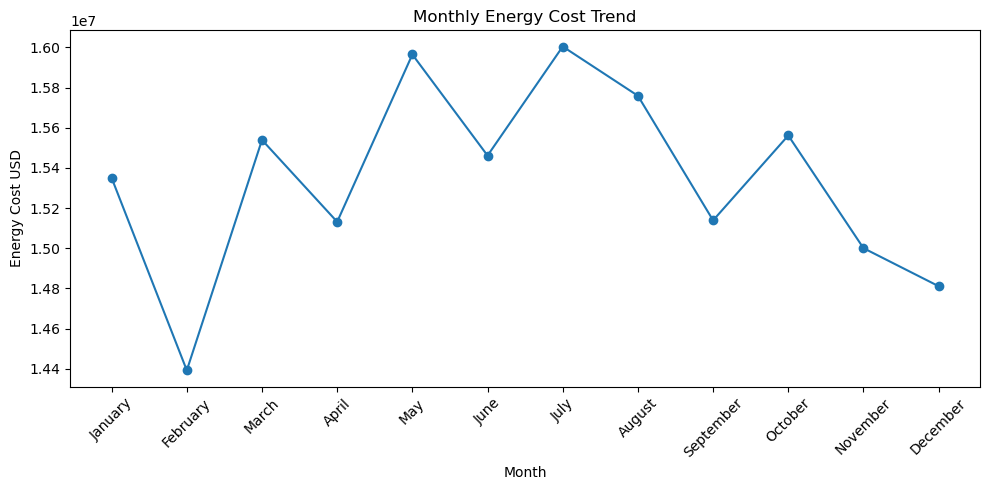

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_trend["month_name"], monthly_trend["total_energy_cost_usd"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Energy Cost Trend")
plt.xlabel("Month")
plt.ylabel("Energy Cost USD")
plt.tight_layout()
plt.show()

### Monthly Trend Insight

The monthly trend shows that energy cost and cooling cost increase during hotter months.

July has the highest total energy cost at approximately `$16.0M`, while May and August also show elevated energy costs.

Revenue leakage peaks in July and August, with both months crossing approximately `$3.49M` to `$3.50M`.

Average PUE is also highest around June and July, which suggests that summer heat increases cooling demand and reduces energy efficiency.

Business recommendation:

The company should prepare seasonal cooling optimization plans before summer months. This can include demand forecasting, cooling maintenance, workload shifting, and peak-demand management.

### 4.9 Site Priority Score

This cell creates a management priority score by combining revenue leakage, PUE, emissions, and gross margin risk.

The site with the lowest priority score should be fixed first because it has the strongest combined business, operational, and ESG risk.

In [37]:
site_priority = site_summary.copy()

site_priority["revenue_leakage_rank"] = site_priority["total_revenue_leakage_usd"].rank(ascending=False)
site_priority["pue_rank"] = site_priority["avg_pue"].rank(ascending=False)
site_priority["emissions_rank"] = site_priority["total_scope_2_emissions_tco2e"].rank(ascending=False)
site_priority["margin_risk_rank"] = site_priority["avg_gross_margin"].rank(ascending=True)

site_priority["priority_score"] = (
    site_priority["revenue_leakage_rank"]
    + site_priority["pue_rank"]
    + site_priority["emissions_rank"]
    + site_priority["margin_risk_rank"]
)

site_priority = site_priority.sort_values(by="priority_score", ascending=True)

site_priority[
    [
        "site_name",
        "city",
        "cooling_type",
        "avg_pue",
        "total_revenue_leakage_usd",
        "total_scope_2_emissions_tco2e",
        "avg_gross_margin",
        "priority_score"
    ]
]

,site_name,city,cooling_type,avg_pue,total_revenue_leakage_usd,total_scope_2_emissions_tco2e,avg_gross_margin,priority_score
0,Delhi Enterprise DC,Delhi,Air Cooling,1.847529,10432126.00,202392.91,62.110082,5.0
1,Mumbai Core DC,Mumbai,Air Cooling,1.799797,8635261.40,247169.77,65.922740,7.0
2,Hyderabad Cloud DC,Hyderabad,Hybrid Cooling,1.594715,5032068.37,170034.30,74.263671,14.0
3,Pune Backup DC,Pune,Air Cooling,1.753849,4239047.36,108510.28,68.372164,15.0
4,Bengaluru AI Hub,Bengaluru,Liquid Cooling,1.448471,3345859.35,156916.40,78.326712,19.0


### Site Priority Score Insight

The site priority score shows that Delhi Enterprise DC should be the first improvement priority.

Delhi Enterprise DC has the lowest priority score of `5.0`, meaning it has the strongest combined business, operational, and ESG risk. It has the highest revenue leakage, worst PUE, high Scope 2 emissions, and the lowest gross margin.

Mumbai Core DC is the second priority with a score of `7.0`. It has the highest Scope 2 emissions and second-highest revenue leakage.

Bengaluru AI Hub has the lowest priority risk with a score of `19.0`, supported by liquid cooling, the best PUE, lowest revenue leakage, and highest gross margin.

Business recommendation:

Management should first invest in Delhi Enterprise DC for cooling optimization, energy efficiency improvement, server utilization improvement, and renewable energy planning. Mumbai Core DC should be the second priority, especially for carbon reduction and renewable energy procurement.

### 4.10 Save EDA Output Files

This cell saves the EDA outputs as CSV files so they can be used later for dashboarding, SQL analysis, reporting, and portfolio documentation.

In [38]:
executive_summary_df.to_csv("executive_summary_kpis.csv", index=False)
revenue_leakage_ranking.to_csv("revenue_leakage_ranking.csv", index=False)
pue_ranking.to_csv("pue_ranking.csv", index=False)
emissions_ranking.to_csv("emissions_ranking.csv", index=False)
server_waste_analysis.to_csv("server_waste_analysis.csv", index=False)
monthly_trend.to_csv("monthly_trend.csv", index=False)
site_priority.to_csv("site_priority_score.csv", index=False)

print("EDA output files saved successfully")

EDA output files saved successfully


## Step 4: Exploratory Data Analysis Summary

In this step, exploratory data analysis was performed to identify the main business, ESG, and operational drivers of data center energy waste.

The analysis found that Delhi Enterprise DC is the highest-priority site for improvement because it has the highest revenue leakage, weakest PUE, high Scope 2 emissions, and lowest gross margin.

Mumbai Core DC is the second priority because it has the highest Scope 2 emissions and high cooling cost.

The temperature and cooling analysis showed that higher temperatures are positively correlated with cooling cost and PUE, confirming that cooling is a major operational cost driver.

The server utilization analysis showed that high idle server rates are contributing to energy waste, especially at Mumbai Core DC and Delhi Enterprise DC.

The monthly trend analysis showed that energy cost, cooling cost, revenue leakage, and PUE increase during hotter months, especially around May to August.

The site priority score combines revenue leakage, PUE, emissions, and margin risk into one management ranking. This gives leadership a clear decision-making framework for where to invest first.

The EDA outputs were saved as CSV files and will be used for dashboard building, SQL business questions, and machine learning model development.

## Step 5: SQL Business Questions using PostgreSQL

### What we are going to do

In this step, we will load the project dataset into PostgreSQL and use SQL queries to answer business questions.

We will use SQL to find:

- Which data center has the highest revenue leakage
- Which site has the worst PUE
- Which site has the highest Scope 2 emissions
- Which cooling type performs best
- Which month has the highest energy cost
- Which site should be prioritized first
- Which sites have high energy waste and poor margins

The goal of this step is to show SQL business analysis skills using PostgreSQL.

## Step 5: SQL Business Questions using PostgreSQL

### What we are going to do

In this step, we will use PostgreSQL to answer business questions from the feature-engineered data center ESG dataset.

The SQL analysis will focus on:

- Revenue leakage
- PUE efficiency
- Scope 2 emissions
- Cooling cost
- Server utilization
- Monthly energy trends
- Site priority ranking

The goal is to show how SQL can be used to convert sustainability and operational data into business decisions.

# 5.1 Upload CSV to PostgreSQL from Jupyter 

In [45]:
import pandas as pd
from sqlalchemy import create_engine, text

DB_USER = "ruchigaur"
DB_PASSWORD = "50million"
DB_HOST = "127.0.0.1"
DB_PORT = "5432"
DB_NAME = "data_center_esg_ml"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_user, current_database();"))
    print(result.fetchone())

OperationalError: (psycopg2.OperationalError) connection to server at "127.0.0.1", port 5432 failed: FATAL:  database "data_center_esg_ml" does not exist

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [46]:
from sqlalchemy import create_engine, text

DB_USER = "ruchigaur"
DB_PASSWORD = "50million"
DB_HOST = "127.0.0.1"
DB_PORT = "5432"

NEW_DB_NAME = "data_center_esg_ml"

# Connect to default postgres database first
default_engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/postgres"
)

with default_engine.connect() as conn:
    conn = conn.execution_options(isolation_level="AUTOCOMMIT")
    
    result = conn.execute(
        text("SELECT 1 FROM pg_database WHERE datname = :db_name"),
        {"db_name": NEW_DB_NAME}
    )
    
    if result.fetchone():
        print(f"Database '{NEW_DB_NAME}' already exists")
    else:
        conn.execute(text(f"CREATE DATABASE {NEW_DB_NAME}"))
        print(f"Database '{NEW_DB_NAME}' created successfully")

Database 'data_center_esg_ml' created successfully


In [47]:
DB_NAME = "data_center_esg_ml"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_user, current_database();"))
    print(result.fetchone())

('ruchigaur', 'data_center_esg_ml')


In [48]:
import pandas as pd

df_sql = pd.read_csv("feature_engineered_data_center_esg_ml_dataset.csv")
site_priority_sql = pd.read_csv("site_priority_score.csv")

df_sql.to_sql(
    "data_center_daily",
    engine,
    if_exists="replace",
    index=False
)

site_priority_sql.to_sql(
    "site_priority_score",
    engine,
    if_exists="replace",
    index=False
)

print("Tables uploaded successfully")
print("data_center_daily rows:", len(df_sql))
print("site_priority_score rows:", len(site_priority_sql))

Tables uploaded successfully
data_center_daily rows: 1825
site_priority_score rows: 5


### 5.2 Verify PostgreSQL Tables

This step confirms that the project tables were successfully uploaded into PostgreSQL.

In [49]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

tables = pd.read_sql(query, engine)
tables

,table_name
0,data_center_daily
1,site_priority_score


## Step 6: Machine Learning Model Development

### What we are going to do

In this step, we will build machine learning models to predict energy waste cost and operational risk.

We will build:

- A regression model to predict `energy_waste_cost_usd`
- A classification model to predict `risk_level`
- Model evaluation using MAE, RMSE, R², accuracy, precision, recall, and F1-score
- Feature importance analysis to identify the main drivers of energy waste and risk

The goal is to show how machine learning can help a business predict energy waste before it becomes a financial and ESG problem.

### 6.1 Load Feature-Engineered Dataset

This cell loads the final feature-engineered dataset created in Step 3.

In [50]:
import pandas as pd
import numpy as np

df_ml = pd.read_csv("feature_engineered_data_center_esg_ml_dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df_ml.shape)

df_ml.head()

Dataset loaded successfully
Shape: (1825, 68)


,date,site_id,site_name,city,country,capacity_mw,cooling_type,energy_tariff_per_kwh,grid_emission_factor,renewable_energy_percent,...,idle_server_rate_percent,energy_per_active_server_kwh,emissions_kg_per_usd_revenue,avg_demand_kw,peak_to_average_demand_ratio,pue_gap,pue_gap_percent,pue_status,revenue_leakage_status,carbon_risk_status
0,2024-01-01,DC001,Mumbai Core DC,Mumbai,India,45,Air Cooling,0.110,0.72,18,...,19.365385,266.144000,1.230607,46497.574583,1.267861,0.161,10.387097,Poor,Medium Leakage,High Carbon Risk
1,2024-01-01,DC002,Bengaluru AI Hub,Bengaluru,India,60,Liquid Cooling,0.090,0.62,42,...,22.861111,214.111363,0.550812,49548.937917,1.276783,0.076,5.629630,Good,Low Leakage,Medium Carbon Risk
2,2024-01-01,DC003,Delhi Enterprise DC,Delhi,India,35,Air Cooling,0.120,0.75,15,...,42.439024,320.941873,1.082185,31559.284167,1.245216,0.160,10.322581,Poor,Low Leakage,Medium Carbon Risk
3,2024-01-01,DC004,Hyderabad Cloud DC,Hyderabad,India,50,Hybrid Cooling,0.100,0.66,35,...,38.721311,281.924508,0.708368,43909.742083,1.326999,0.110,7.586207,Good,Low Leakage,Medium Carbon Risk
4,2024-01-01,DC005,Pune Backup DC,Pune,India,30,Air Cooling,0.095,0.68,28,...,32.424242,267.409000,0.909443,24846.752917,1.239971,0.154,9.935484,Poor,Low Leakage,Low Carbon Risk


### 6.2 Check Machine Learning Target Variables

Before building models, we check the two target variables:

- `energy_waste_cost_usd` for regression
- `risk_level` for classification

In [51]:
print("Regression target summary:")
print(df_ml["energy_waste_cost_usd"].describe())

print("\nClassification target distribution:")
print(df_ml["risk_level"].value_counts())

print("\nClassification target percentage:")
print(df_ml["risk_level"].value_counts(normalize=True) * 100)

Regression target summary:
count     1825.000000
mean     11638.445518
std       5455.882964
min       2511.930000
25%       7055.140000
50%      10167.290000
75%      15884.070000
max      29137.370000
Name: energy_waste_cost_usd, dtype: float64

Classification target distribution:
risk_level
Medium    1160
High       518
Low        147
Name: count, dtype: int64

Classification target percentage:
risk_level
Medium    63.561644
High      28.383562
Low        8.054795
Name: proportion, dtype: float64


### 6.3 Select ML Features

The feature set includes operational, environmental, infrastructure, and workload variables.

Target leakage columns are excluded so that the model does not learn from columns that directly contain the answer.

In [52]:
# Features used for machine learning

ml_features = [
    "capacity_mw",
    "cooling_type",
    "energy_tariff_per_kwh",
    "grid_emission_factor",
    "renewable_energy_percent",
    "building_age_years",
    "temperature_celsius",
    "humidity_percent",
    "server_count",
    "active_servers",
    "idle_servers",
    "avg_cpu_utilization_percent",
    "storage_utilization_percent",
    "ai_workload_percent",
    "peak_demand_kw",
    "month",
    "quarter",
    "is_weekend"
]

X = df_ml[ml_features]

y_regression = df_ml["energy_waste_cost_usd"]
y_classification = df_ml["risk_level"]

print("Feature dataset shape:", X.shape)
print("Regression target shape:", y_regression.shape)
print("Classification target shape:", y_classification.shape)

Feature dataset shape: (1825, 18)
Regression target shape: (1825,)
Classification target shape: (1825,)


### 6.4 Train-Test Split and Preprocessing

The dataset is split into training and testing data.

Numeric features are scaled and categorical features are one-hot encoded.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_features = [
    "capacity_mw",
    "energy_tariff_per_kwh",
    "grid_emission_factor",
    "renewable_energy_percent",
    "building_age_years",
    "temperature_celsius",
    "humidity_percent",
    "server_count",
    "active_servers",
    "idle_servers",
    "avg_cpu_utilization_percent",
    "storage_utilization_percent",
    "ai_workload_percent",
    "peak_demand_kw",
    "month",
    "quarter",
    "is_weekend"
]

categorical_features = ["cooling_type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

# Classification split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Regression training shape:", X_train_reg.shape)
print("Regression testing shape:", X_test_reg.shape)

print("Classification training shape:", X_train_cls.shape)
print("Classification testing shape:", X_test_cls.shape)

Regression training shape: (1460, 18)
Regression testing shape: (365, 18)
Classification training shape: (1460, 18)
Classification testing shape: (365, 18)


### 6.5 Regression Model: Predict Energy Waste Cost

This model predicts the daily energy waste cost for a data center.

Business use:

The company can use this prediction to estimate how much money may be lost due to inefficient energy usage and take preventive action.

In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            max_depth=12
        ))
    ]
)

regression_model.fit(X_train_reg, y_train_reg)

y_pred_reg = regression_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Performance")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 3))

Regression Model Performance
MAE: 1445.31
RMSE: 1814.31
R2 Score: 0.891


### Regression Model Interpretation

The regression model predicts `energy_waste_cost_usd`, which estimates daily financial loss caused by inefficient energy usage.

MAE shows the average prediction error in USD.

RMSE gives a stronger penalty to larger errors.

R² shows how much variation in energy waste cost is explained by the model.

A stronger R² means the model is useful for forecasting operational cost leakage.

### 6.6 Actual vs Predicted Energy Waste Cost

This table compares actual energy waste cost with the model prediction.

In [59]:
regression_results = pd.DataFrame({
    "actual_energy_waste_cost_usd": y_test_reg.values,
    "predicted_energy_waste_cost_usd": y_pred_reg
})

regression_results["prediction_error_usd"] = (
    regression_results["actual_energy_waste_cost_usd"] 
    - regression_results["predicted_energy_waste_cost_usd"]
)

regression_results.head(10)

,actual_energy_waste_cost_usd,predicted_energy_waste_cost_usd,prediction_error_usd
0,19467.70,16829.239368,2638.460632
1,3693.78,5642.124636,-1948.344636
2,12533.71,15888.628928,-3354.918928
3,13454.00,11380.128673,2073.871327
4,16309.18,16994.245604,-685.065604
5,6958.16,7569.452240,-611.292240
6,10533.54,8397.705713,2135.834287
7,7497.22,5839.024166,1658.195834
8,12976.98,11791.701537,1185.278463
9,21269.47,18958.811744,2310.658256


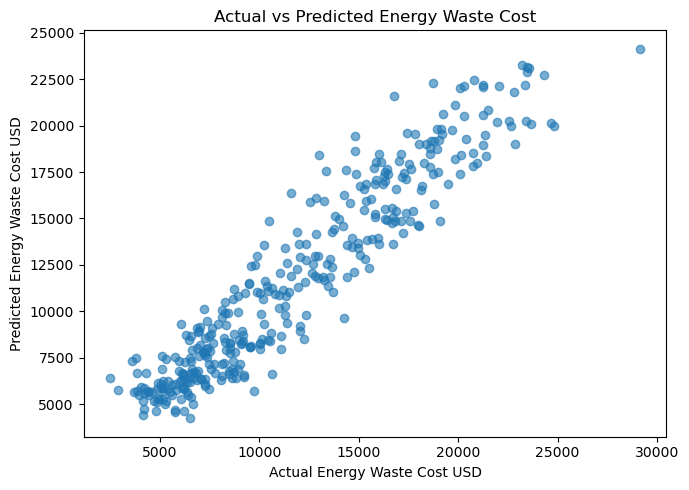

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    regression_results["actual_energy_waste_cost_usd"],
    regression_results["predicted_energy_waste_cost_usd"],
    alpha=0.6
)
plt.xlabel("Actual Energy Waste Cost USD")
plt.ylabel("Predicted Energy Waste Cost USD")
plt.title("Actual vs Predicted Energy Waste Cost")
plt.tight_layout()
plt.show()

### 6.7 Classification Model: Predict Risk Level

This model predicts whether a data center operating day is Low, Medium, or High risk.

Business use:

The company can use this model to identify risky site-days earlier and prioritize operational intervention.

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

classification_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            max_depth=12,
            class_weight="balanced"
        ))
    ]
)

classification_model.fit(X_train_cls, y_train_cls)

y_pred_cls = classification_model.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)

print("Classification Model Performance")
print("Accuracy:", round(accuracy, 3))

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

Classification Model Performance
Accuracy: 0.871

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.80      0.83       104
         Low       0.87      0.69      0.77        29
      Medium       0.88      0.93      0.90       232

    accuracy                           0.87       365
   macro avg       0.87      0.80      0.83       365
weighted avg       0.87      0.87      0.87       365



### Classification Model Interpretation

The classification model predicts whether a data center operating day is Low, Medium, or High risk.

Accuracy shows the overall percentage of correct predictions.

Precision shows how reliable the model is when it predicts a risk class.

Recall shows how well the model captures actual risk cases.

F1-score balances precision and recall.

For business use, recall for High Risk is especially important because missing a high-risk day can lead to higher cost, emissions, and SLA penalties.

### 6.8 Confusion Matrix

The confusion matrix shows where the classification model predicted correctly and where it confused one risk level with another.

In [63]:
labels = ["Low", "Medium", "High"]

conf_matrix = confusion_matrix(y_test_cls, y_pred_cls, labels=labels)

confusion_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

confusion_matrix_df

,Predicted Low,Predicted Medium,Predicted High
Actual Low,20,9,0
Actual Medium,3,215,14
Actual High,0,21,83


### 6.9 Feature Importance

Feature importance explains which variables had the strongest influence on the model prediction.

This makes the ML model easier to explain to business stakeholders.

In [65]:
# Get transformed feature names

encoded_cat_features = (
    classification_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + list(encoded_cat_features)

feature_importance_values = (
    classification_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": feature_importance_values
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
13,peak_demand_kw,0.135304
5,temperature_celsius,0.081900
16,is_weekend,0.070427
2,grid_emission_factor,0.068070
4,building_age_years,0.061678
3,renewable_energy_percent,0.056351
7,server_count,0.054924
9,idle_servers,0.052011
0,capacity_mw,0.051251
10,avg_cpu_utilization_percent,0.050056


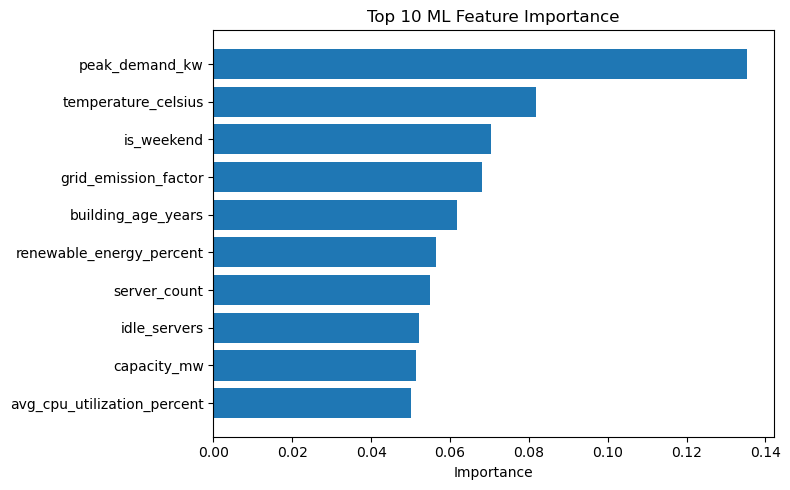

In [66]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 ML Feature Importance")
plt.tight_layout()
plt.show()

### Feature Importance Insight

The feature importance analysis shows which factors most strongly influence energy waste and risk prediction.

Features such as peak demand, temperature, building age, cooling type, server activity, and workload intensity are expected to be important drivers.

This helps convert the ML model into business recommendations such as improving cooling systems, managing peak demand, reducing idle servers, and optimizing workload scheduling.

### 6.10 Save Machine Learning Outputs

This cell saves the model results and feature importance outputs for reporting and dashboard use.

In [67]:
regression_results.to_csv("ml_regression_predictions.csv", index=False)
confusion_matrix_df.to_csv("ml_classification_confusion_matrix.csv")
feature_importance_df.to_csv("ml_feature_importance.csv", index=False)

ml_summary = pd.DataFrame({
    "metric": [
        "regression_mae",
        "regression_rmse",
        "regression_r2",
        "classification_accuracy"
    ],
    "value": [
        mae,
        rmse,
        r2,
        accuracy
    ]
})

ml_summary.to_csv("ml_model_summary.csv", index=False)

print("ML output files saved successfully")
print("Saved files:")
print("1. ml_regression_predictions.csv")
print("2. ml_classification_confusion_matrix.csv")
print("3. ml_feature_importance.csv")
print("4. ml_model_summary.csv")

ML output files saved successfully
Saved files:
1. ml_regression_predictions.csv
2. ml_classification_confusion_matrix.csv
3. ml_feature_importance.csv
4. ml_model_summary.csv


## Step 6: Machine Learning Model Development Summary

In this step, two machine learning models were built.

The regression model predicted `energy_waste_cost_usd`, helping estimate daily financial loss from inefficient energy usage.

The classification model predicted `risk_level`, helping identify Low, Medium, and High risk operating days.

The models used operational, environmental, infrastructure, and workload features such as temperature, humidity, cooling type, building age, server utilization, AI workload, peak demand, and energy tariff.

Feature importance was used to explain which factors most strongly influence energy waste and risk.

The machine learning results can help the business move from historical reporting to predictive decision-making.

Instead of only asking where energy waste happened, the company can now estimate where energy waste is likely to happen next and take action earlier.

##The project moved beyond descriptive ESG reporting into predictive analytics.

A regression model was built to estimate daily energy waste cost, helping the business forecast potential financial loss from inefficient energy usage.

A classification model was built to predict operating risk level, helping the business identify Low, Medium, and High risk site-days before they become larger cost or ESG issues.

Feature importance was used to explain the main drivers of risk, making the ML model interpretable for business stakeholders.